# Observation Direct Transfer Summary Table

This notebook reads the copied observation logs from `logs/sim2real_observations/presslight` and summarizes the available comparison methods:

- `direct_transfer` for each network and setting
- `domain_randomization` for each network and setting

Method-specific metric rules:

- `direct_transfer`: use the `TEST_REAL` row at episode `1` from the newest copied observation DTL log for that network and setting
- `domain_randomization`: take the top `TOP_REWARD_K` real/equivalent rows by reward from `TEST_REAL` or `TRAIN_REAL` rows in the newest available DR DTL log, then average their metrics

`cityflow_direct_transfer` is loaded internally as the baseline used to compute gaps, but it is not shown as a comparison method in the gap table or plots. The gap chart remains ATT-based: it plots the selected rows' average travel time minus the cityflow direct-transfer travel time.



In [1]:
from pathlib import Path
import re
import numpy as np

import pandas as pd

LOG_ROOT = Path('logs/sim2real_observations/presslight')
TOP_REWARD_K = 5
DIRECT_TRANSFER_EPISODE = 1

NETWORK_ORDER = [
    network
    for network in ['tempe_1x1', 'bullhead_1', 'cologne1', 'ingolstadt1', 'hz1x1', 'tempe_16', 'bullhead_3', 'cologne3', 'ingolstadt7', 'hz4x4']
    if (LOG_ROOT / network).exists()
]
if not NETWORK_ORDER:
    NETWORK_ORDER = sorted(path.name for path in LOG_ROOT.iterdir() if path.is_dir())

SETTING_ORDER = ['setting1', 'setting2', 'setting3', 'setting4']
METHOD_ORDER = [
    'direct_transfer',
    'domain_randomization',
]

COLUMNS = [
    'exp_name',
    'mode',
    'episode',
    'travel_time',
    'aux',
    'reward',
    'queue',
    'delay',
    'throughput',
]

METRIC_COLUMNS = ['travel_time', 'aux', 'reward', 'queue', 'delay', 'throughput']
NUMERIC_COLUMNS = ['episode', *METRIC_COLUMNS]
TEXT_REAL_ROLLOUT_RE = re.compile(r'^Real rollout step:(?P<episode>\d+)/\d+, travel time:(?P<travel_time>-?\d+(?:\.\d+)?)')




In [2]:
# NETWORK_ORDER = ['tempe_1x1']
# SETTING_ORDER = ['setting1']


In [3]:
def read_tabular_dtl(log_path: Path):
    df = pd.read_csv(log_path, sep='	', header=None, names=COLUMNS)
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def empty_metric_result(log_file=pd.NA):
    result = {column: pd.NA for column in METRIC_COLUMNS}
    for column in METRIC_COLUMNS:
        result[f'{column}_std'] = pd.NA
    result.update(
        {
            'episode': pd.NA,
            'selected_episodes': pd.NA,
            'selection_count': 0,
            'log_file': log_file,
        }
    )
    return result


def metric_result_from_row(row, log_path: Path | None = None):
    result = {}
    for column in METRIC_COLUMNS:
        value = pd.to_numeric(row[column], errors='coerce')
        result[column] = float(value) if pd.notna(value) else pd.NA
        result[f'{column}_std'] = pd.NA

    episode = pd.to_numeric(row['episode'], errors='coerce')
    episode = int(episode) if pd.notna(episode) else pd.NA

    result.update(
        {
            'episode': episode,
            'selected_episodes': str(episode) if pd.notna(episode) else pd.NA,
            'selection_count': 1,
            'log_file': log_path.name if log_path is not None else pd.NA,
        }
    )
    return result


def metric_result_from_top_reward_rows(rows, log_path: Path, top_k: int = TOP_REWARD_K):
    selected_df = rows.sort_values('reward', ascending=False).head(top_k).copy()
    if selected_df.empty:
        return empty_metric_result(log_path.name)

    result = {}
    for column in METRIC_COLUMNS:
        values = selected_df[column].dropna()
        result[column] = float(values.mean()) if not values.empty else pd.NA
        result[f'{column}_std'] = float(values.std(ddof=1)) if len(values) > 1 else pd.NA

    episodes = selected_df['episode'].dropna()
    selected_episodes = ', '.join(str(int(episode)) for episode in episodes)
    result.update(
        {
            'episode': float(episodes.mean()) if not episodes.empty else pd.NA,
            'selected_episodes': selected_episodes if selected_episodes else pd.NA,
            'selection_count': int(len(selected_df)),
            'log_file': log_path.name,
        }
    )
    return result


def read_top_reward_average_dtl_modes(log_path: Path, modes, top_k: int = TOP_REWARD_K):
    df = read_tabular_dtl(log_path)
    mode_df = df[df['mode'].isin(modes)].copy()
    mode_df = mode_df[mode_df['travel_time'].notna() & mode_df['reward'].notna()]
    if mode_df.empty:
        return empty_metric_result(log_path.name)

    return metric_result_from_top_reward_rows(mode_df, log_path, top_k=top_k)


def read_latest_top_reward_average_result(candidate_dirs, modes, top_k: int = TOP_REWARD_K):
    log_files = []
    for log_dir in candidate_dirs:
        if log_dir.exists():
            log_files.extend(log_dir.glob('*_DTL.log'))

    for log_path in sorted(log_files, key=lambda path: (path.name, str(path)), reverse=True):
        result = read_top_reward_average_dtl_modes(log_path, modes, top_k=top_k)
        if pd.notna(result['travel_time']):
            return result

    return empty_metric_result()


def read_direct_transfer_test_real(log_path: Path, target_episode: int = DIRECT_TRANSFER_EPISODE):
    df = read_tabular_dtl(log_path)
    real_df = df[df['mode'] == 'TEST_REAL'].copy()
    real_df = real_df[real_df['travel_time'].notna()]
    if real_df.empty:
        return empty_metric_result(log_path.name)

    target_df = real_df[real_df['episode'] == target_episode].copy()
    if not target_df.empty:
        return metric_result_from_row(target_df.iloc[0], log_path)

    earliest_df = real_df.sort_values('episode', ascending=True).head(1)
    return metric_result_from_row(earliest_df.iloc[0], log_path)


def read_observation_direct_transfer_result(network: str, setting: str):
    candidate_dirs = [LOG_ROOT / network / 'domain_randomization' / setting]
    log_files = []
    for log_dir in candidate_dirs:
        if log_dir.exists():
            log_files.extend(log_dir.glob('*_DTL.log'))

    for log_path in sorted(log_files, key=lambda path: (path.name, str(path)), reverse=True):
        result = read_direct_transfer_test_real(log_path)
        if pd.notna(result['travel_time']):
            return result

    return empty_metric_result()


def read_cityflow_direct_transfer_result(network: str):
    log_dir = LOG_ROOT / network / 'cityflow_direct_transfer'
    log_files = sorted(log_dir.glob('*_DTL.log')) if log_dir.exists() else []
    if not log_files:
        return empty_metric_result()
    return read_direct_transfer_final_test(log_files[-1])


def read_direct_transfer_final_test(log_path: Path):
    df = read_tabular_dtl(log_path)
    final_df = df[df['mode'] == 'FINAL_TEST'].copy()
    if final_df.empty:
        return empty_metric_result(log_path.name)
    return metric_result_from_row(final_df.iloc[-1], log_path)


def read_domain_randomization_result(network: str, setting: str):
    candidate_dirs = [
        LOG_ROOT / network / 'domain_randomization_eval' / setting,
        LOG_ROOT / network / 'domain_randomization' / setting,
    ]
    return read_latest_top_reward_average_result(candidate_dirs, ['TEST_REAL', 'TRAIN_REAL'])


def store_method_result(row, method: str, result):
    row[method] = result['travel_time']
    for column in METRIC_COLUMNS:
        row[f'{method}_{column}'] = result[column]
        row[f'{method}_{column}_std'] = result.get(f'{column}_std', pd.NA)
    row[f'{method}_episode'] = result['episode']
    row[f'{method}_selected_episodes'] = result['selected_episodes']
    row[f'{method}_selection_count'] = result['selection_count']
    row[f'{method}_log_file'] = result['log_file']


def format_method_cell(value, selection_count, throughput):
    if pd.isna(value):
        return pd.NA
    parts = []
    if pd.notna(selection_count) and int(selection_count) > 1:
        parts.append(f'n {int(selection_count)}')
    if pd.notna(throughput):
        parts.append(f'tp {int(throughput)}' if float(throughput).is_integer() else f'tp {throughput:.1f}')
    details = ', '.join(parts)
    return f'{value:.1f} ({details})' if details else f'{value:.1f}'


method_rows = []
for network in NETWORK_ORDER:
    cityflow_result = read_cityflow_direct_transfer_result(network)

    for setting in SETTING_ORDER:
        row = {
            'network': network,
            'setting': setting,
        }
        store_method_result(row, 'cityflow_direct_transfer', cityflow_result)
        store_method_result(row, 'direct_transfer', read_observation_direct_transfer_result(network, setting))
        store_method_result(row, 'domain_randomization', read_domain_randomization_result(network, setting))
        method_rows.append(row)

method_df = pd.DataFrame(method_rows)
method_df = method_df.round(1)
method_df




,network,setting,cityflow_direct_transfer,cityflow_direct_transfer_travel_time,cityflow_direct_transfer_travel_time_std,cityflow_direct_transfer_aux,cityflow_direct_transfer_aux_std,cityflow_direct_transfer_reward,cityflow_direct_transfer_reward_std,cityflow_direct_transfer_queue,...,domain_randomization_queue,domain_randomization_queue_std,domain_randomization_delay,domain_randomization_delay_std,domain_randomization_throughput,domain_randomization_throughput_std,domain_randomization_episode,domain_randomization_selected_episodes,domain_randomization_selection_count,domain_randomization_log_file
0,tempe_1x1,setting1,143.0,143.0,<NA>,100.0,<NA>,-10.3,<NA>,5.4,...,26.6,1.5,1.4,0.1,1871.4,3.0,80.2,"56, 72, 68, 118, 87",5,2026_05_18-02_05_32_DTL.log
1,tempe_1x1,setting2,143.0,143.0,<NA>,100.0,<NA>,-10.3,<NA>,5.4,...,27.4,1.5,1.3,0.1,1868.2,6.2,135.0,"223, 31, 222, 95, 104",5,2026_05_18-02_24_47_DTL.log
2,tempe_1x1,setting3,143.0,143.0,<NA>,100.0,<NA>,-10.3,<NA>,5.4,...,24.4,0.7,1.2,0.0,1870.2,1.6,118.6,"23, 169, 176, 106, 119",5,2026_05_18-02_46_22_DTL.log
3,tempe_1x1,setting4,143.0,143.0,<NA>,100.0,<NA>,-10.3,<NA>,5.4,...,34.8,5.9,1.7,0.3,1869.6,3.4,233.2,"234, 270, 273, 180, 209",5,2026_05_18-03_06_13_DTL.log


In [4]:
method_table_df = method_df.set_index(['network', 'setting'])[METHOD_ORDER].sort_index()
method_selection_count_df = method_df.set_index(['network', 'setting'])[[f'{method}_selection_count' for method in METHOD_ORDER]].sort_index()
method_selection_count_df.columns = METHOD_ORDER
method_throughput_df = method_df.set_index(['network', 'setting'])[[f'{method}_throughput' for method in METHOD_ORDER]].sort_index()
method_throughput_df.columns = METHOD_ORDER
method_table_display_df = method_table_df.copy()
for method in METHOD_ORDER:
    method_table_display_df[method] = [
        format_method_cell(value, selection_count, throughput)
        for value, selection_count, throughput in zip(method_table_df[method], method_selection_count_df[method], method_throughput_df[method])
    ]

method_metric_rows = []
for _, row in method_df.iterrows():
    for method in METHOD_ORDER:
        if pd.isna(row.get(method, pd.NA)):
            continue
        method_metric_rows.append(
            {
                'network': row['network'],
                'setting': row['setting'],
                'method': method,
                'travel_time': row.get(method, pd.NA),
                'reward': row.get(f'{method}_reward', pd.NA),
                'queue': row.get(f'{method}_queue', pd.NA),
                'delay': row.get(f'{method}_delay', pd.NA),
                'throughput': row.get(f'{method}_throughput', pd.NA),
                'selection_count': row.get(f'{method}_selection_count', pd.NA),
                'selected_episodes': row.get(f'{method}_selected_episodes', pd.NA),
            }
        )

method_metric_df = pd.DataFrame(method_metric_rows).round(1)

display(method_table_display_df)
display(method_metric_df)


direct_transfer    domain_randomization
network   setting                                          
tempe_1x1 setting1  166.2 (tp 1859)  148.8 (n 5, tp 1871.4)
          setting2  187.5 (tp 1859)  152.2 (n 5, tp 1868.2)
          setting3  531.5 (tp 1517)  150.5 (n 5, tp 1870.2)
          setting4  639.0 (tp 1311)  153.3 (n 5, tp 1869.6)

,network,setting,method,travel_time,reward,queue,delay,throughput,selection_count,selected_episodes
0,tempe_1x1,setting1,direct_transfer,166.2,-23.1,25.3,1.1,1859.0,1,1
1,tempe_1x1,setting1,domain_randomization,148.8,-13.6,26.6,1.4,1871.4,5,"56, 72, 68, 118, 87"
2,tempe_1x1,setting2,direct_transfer,187.5,-34.4,30.1,1.1,1859.0,1,1
3,tempe_1x1,setting2,domain_randomization,152.2,-15.5,27.4,1.3,1868.2,5,"223, 31, 222, 95, 104"
4,tempe_1x1,setting3,direct_transfer,531.5,-229.7,162.7,1.1,1517.0,1,1
5,tempe_1x1,setting3,domain_randomization,150.5,-14.5,24.4,1.2,1870.2,5,"23, 169, 176, 106, 119"
6,tempe_1x1,setting4,direct_transfer,639.0,-293.1,227.8,1.7,1311.0,1,1
7,tempe_1x1,setting4,domain_randomization,153.3,-16.0,34.8,1.7,1869.6,5,"234, 270, 273, 180, 209"


## Method Availability


In [5]:
availability_rows = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        row = method_df[(method_df['network'] == network) & (method_df['setting'] == setting)]
        if row.empty:
            continue
        row = row.iloc[-1]
        availability_rows.append(
            {
                'network': network,
                'setting': setting,
                **{method: pd.notna(row[method]) for method in METHOD_ORDER},
            }
        )

availability_df = pd.DataFrame(availability_rows)
availability_df


,network,setting,direct_transfer,domain_randomization
0,tempe_1x1,setting1,True,True
1,tempe_1x1,setting2,True,True
2,tempe_1x1,setting3,True,True
3,tempe_1x1,setting4,True,True


## Gap Comparison


In [6]:
comparison_rows = []
for _, row in method_df.iterrows():
    cityflow_reference = row.get('cityflow_direct_transfer', pd.NA)

    for method in METHOD_ORDER:
        value = row.get(method, pd.NA)
        if pd.isna(value):
            continue

        gap = pd.NA
        if pd.notna(cityflow_reference):
            gap = float(value - cityflow_reference)

        comparison_rows.append(
            {
                'network': row['network'],
                'setting': row['setting'],
                'method': method,
                'travel_time': value,
                'travel_time_std': row.get(f'{method}_travel_time_std', pd.NA),
                'reward': row.get(f'{method}_reward', pd.NA),
                'queue': row.get(f'{method}_queue', pd.NA),
                'delay': row.get(f'{method}_delay', pd.NA),
                'throughput': row.get(f'{method}_throughput', pd.NA),
                'selection_count': row.get(f'{method}_selection_count', pd.NA),
                'selected_episodes': row.get(f'{method}_selected_episodes', pd.NA),
                'cityflow_direct_transfer': cityflow_reference,
                'gap_vs_cityflow': gap,
                'log_file': row.get(f'{method}_log_file', pd.NA),
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.round(1)
comparison_df = comparison_df[
    [
        'network',
        'setting',
        'method',
        'travel_time',
        'travel_time_std',
        'reward',
        'queue',
        'delay',
        'throughput',
        'selection_count',
        'selected_episodes',
        'cityflow_direct_transfer',
        'gap_vs_cityflow',
        'log_file',
    ]
]
comparison_df



,network,setting,method,travel_time,travel_time_std,reward,queue,delay,throughput,selection_count,selected_episodes,cityflow_direct_transfer,gap_vs_cityflow,log_file
0,tempe_1x1,setting1,direct_transfer,166.2,<NA>,-23.1,25.3,1.1,1859.0,1,1,143.0,23.2,2026_05_18-02_05_32_DTL.log
1,tempe_1x1,setting1,domain_randomization,148.8,0.7,-13.6,26.6,1.4,1871.4,5,"56, 72, 68, 118, 87",143.0,5.8,2026_05_18-02_05_32_DTL.log
2,tempe_1x1,setting2,direct_transfer,187.5,<NA>,-34.4,30.1,1.1,1859.0,1,1,143.0,44.5,2026_05_18-02_24_47_DTL.log
3,tempe_1x1,setting2,domain_randomization,152.2,0.6,-15.5,27.4,1.3,1868.2,5,"223, 31, 222, 95, 104",143.0,9.2,2026_05_18-02_24_47_DTL.log
4,tempe_1x1,setting3,direct_transfer,531.5,<NA>,-229.7,162.7,1.1,1517.0,1,1,143.0,388.5,2026_05_18-02_46_22_DTL.log
5,tempe_1x1,setting3,domain_randomization,150.5,0.3,-14.5,24.4,1.2,1870.2,5,"23, 169, 176, 106, 119",143.0,7.5,2026_05_18-02_46_22_DTL.log
6,tempe_1x1,setting4,direct_transfer,639.0,<NA>,-293.1,227.8,1.7,1311.0,1,1,143.0,496.0,2026_05_18-03_06_13_DTL.log
7,tempe_1x1,setting4,domain_randomization,153.3,0.4,-16.0,34.8,1.7,1869.6,5,"234, 270, 273, 180, 209",143.0,10.3,2026_05_18-03_06_13_DTL.log


## Gap Bar Chart


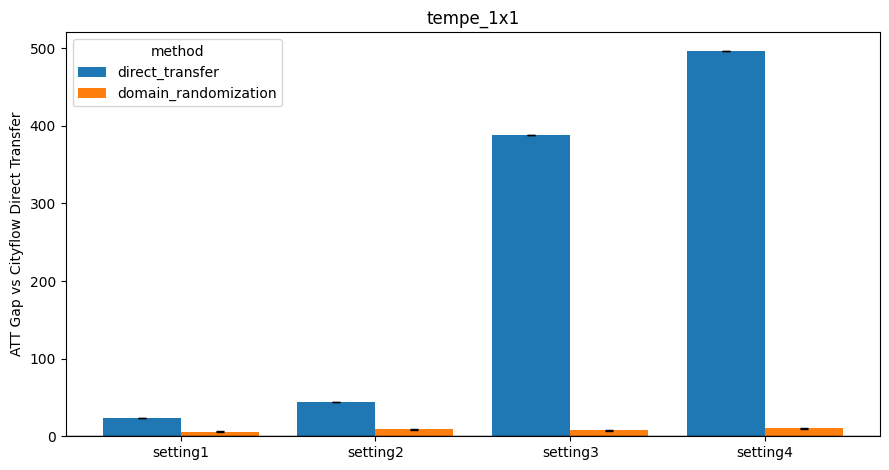

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for network in NETWORK_ORDER:
    plot_df = comparison_df[comparison_df['network'] == network].copy()
    if plot_df.empty:
        continue

    pivot_df = (
        plot_df.pivot(index='setting', columns='method', values='gap_vs_cityflow')
        .reindex(SETTING_ORDER)
    )
    error_df = (
        plot_df.pivot(index='setting', columns='method', values='travel_time_std')
        .reindex(SETTING_ORDER)
    )
    available_methods = [method for method in METHOD_ORDER if method in pivot_df.columns and pivot_df[method].notna().any()]
    if not available_methods:
        continue

    x = np.arange(len(SETTING_ORDER))
    width = 0.8 / len(available_methods)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    for idx, method in enumerate(available_methods):
        offsets = x - 0.4 + width / 2 + idx * width
        values = pd.to_numeric(pivot_df[method], errors='coerce').to_numpy(dtype=float)
        errors = (
            pd.to_numeric(error_df[method], errors='coerce').to_numpy(dtype=float)
            if method in error_df.columns
            else np.full(len(values), np.nan)
        )
        mask = ~np.isnan(values)
        yerr = np.where(np.isnan(errors[mask]), 0, errors[mask])
        ax.bar(
            offsets[mask],
            values[mask],
            width=width,
            yerr=yerr,
            capsize=3,
            ecolor='black',
            error_kw={'linewidth': 0.9},
            label=method,
        )

    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(SETTING_ORDER)
    ax.set_ylabel('ATT Gap vs Cityflow Direct Transfer')
    ax.set_title(network)
    ax.legend(title='method')
    fig.tight_layout()
    plt.show()



In [8]:
# from pathlib import Path

# GAP_BAR_CHART_DIR = Path('figures/observation_gap_bar_chart')
# GAP_BAR_CHART_DIR.mkdir(parents=True, exist_ok=True)

# saved_gap_chart_paths = []
# for network in NETWORK_ORDER:
#     plot_df = comparison_df[comparison_df['network'] == network].copy()
#     if plot_df.empty:
#         continue

#     pivot_df = (
#         plot_df.pivot(index='setting', columns='method', values='gap_vs_cityflow')
#         .reindex(SETTING_ORDER)
#     )
#     error_df = (
#         plot_df.pivot(index='setting', columns='method', values='travel_time_std')
#         .reindex(SETTING_ORDER)
#     )
#     available_methods = [method for method in METHOD_ORDER if method in pivot_df.columns and pivot_df[method].notna().any()]
#     if not available_methods:
#         continue

#     x = np.arange(len(SETTING_ORDER))
#     width = 0.8 / len(available_methods)

#     fig, ax = plt.subplots(figsize=(9, 4.8))
#     for idx, method in enumerate(available_methods):
#         offsets = x - 0.4 + width / 2 + idx * width
#         values = pd.to_numeric(pivot_df[method], errors='coerce').to_numpy(dtype=float)
#         errors = (
#             pd.to_numeric(error_df[method], errors='coerce').to_numpy(dtype=float)
#             if method in error_df.columns
#             else np.full(len(values), np.nan)
#         )
#         mask = ~np.isnan(values)
#         yerr = np.where(np.isnan(errors[mask]), 0, errors[mask])
#         ax.bar(
#             offsets[mask],
#             values[mask],
#             width=width,
#             yerr=yerr,
#             capsize=3,
#             ecolor='black',
#             error_kw={'linewidth': 0.9},
#             label=method,
#         )

#     ax.axhline(0, color='black', linewidth=1)
#     ax.set_xticks(x)
#     ax.set_xticklabels(SETTING_ORDER)
#     ax.set_ylabel('ATT Gap vs Cityflow Direct Transfer')
#     ax.set_title(network)
#     ax.legend(title='method')
#     fig.tight_layout()

#     save_path = GAP_BAR_CHART_DIR / f'{network}_gap_bar_chart.png'
#     fig.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.close(fig)
#     saved_gap_chart_paths.append(save_path)

# saved_gap_chart_paths



## Picked Metric Mean and Std

This table uses the same picked rows as the summary tables above. Domain randomization is summarized from its top `TOP_REWARD_K` real/equivalent rows by reward; direct transfer is a single `TEST_REAL` episode `1` row, so its standard deviations are left blank. Each metric cell is formatted as `mean ± std` when a standard deviation is available.



In [9]:
def selected_metric_rows_from_modes(log_path: Path, modes, top_k: int = TOP_REWARD_K):
    df = read_tabular_dtl(log_path)
    mode_df = df[df['mode'].isin(modes)].copy()
    mode_df = mode_df[mode_df['travel_time'].notna() & mode_df['reward'].notna()]
    if mode_df.empty:
        return mode_df
    return mode_df.sort_values('reward', ascending=False).head(top_k).copy()


def selected_direct_transfer_rows(log_path: Path, target_episode: int = DIRECT_TRANSFER_EPISODE):
    df = read_tabular_dtl(log_path)
    mode_df = df[df['mode'] == 'TEST_REAL'].copy()
    mode_df = mode_df[mode_df['travel_time'].notna()]
    if mode_df.empty:
        return mode_df
    target_df = mode_df[mode_df['episode'] == target_episode].copy()
    if not target_df.empty:
        return target_df.head(1).copy()
    return mode_df.sort_values('episode', ascending=True).head(1).copy()


def selected_metric_rows_for_method(network: str, setting: str, method: str):
    row_df = comparison_df[
        (comparison_df['network'] == network)
        & (comparison_df['setting'] == setting)
        & (comparison_df['method'] == method)
    ]
    if row_df.empty or pd.isna(row_df.iloc[-1]['log_file']):
        return pd.DataFrame(), None

    log_file = row_df.iloc[-1]['log_file']
    if method == 'direct_transfer':
        candidate_dirs = [LOG_ROOT / network / 'domain_randomization' / setting]
        use_top_reward = False
    elif method == 'domain_randomization':
        candidate_dirs = [
            LOG_ROOT / network / 'domain_randomization_eval' / setting,
            LOG_ROOT / network / 'domain_randomization' / setting,
        ]
        use_top_reward = True
    else:
        return pd.DataFrame(), None

    log_path = next((candidate_dir / log_file for candidate_dir in candidate_dirs if (candidate_dir / log_file).exists()), None)
    if log_path is None:
        return pd.DataFrame(), None

    if use_top_reward:
        selected_df = selected_metric_rows_from_modes(log_path, ['TEST_REAL', 'TRAIN_REAL'])
    else:
        selected_df = selected_direct_transfer_rows(log_path)

    return selected_df, log_path


def format_mean_std(mean_value, std_value):
    if pd.isna(mean_value):
        return pd.NA
    if pd.isna(std_value):
        return f'{mean_value:.1f}'
    return f'{mean_value:.1f} ± {std_value:.1f}'


picked_metric_rows = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        for method in METHOD_ORDER:
            selected_df, log_path = selected_metric_rows_for_method(network, setting, method)
            if selected_df.empty:
                continue

            summary_row = {
                'network': network,
                'setting': setting,
                'method': method,
                'selection_count': int(len(selected_df)),
                'selected_episodes': ', '.join(str(int(episode)) for episode in selected_df['episode'].dropna()),
                'log_file': log_path.name,
            }
            for metric in METRIC_COLUMNS:
                values = selected_df[metric].dropna()
                summary_row[f'{metric}_mean'] = float(values.mean()) if not values.empty else pd.NA
                summary_row[f'{metric}_std'] = float(values.std(ddof=1)) if len(values) > 1 else pd.NA
            picked_metric_rows.append(summary_row)

picked_metric_summary_df = pd.DataFrame(picked_metric_rows)

picked_metric_display_df = picked_metric_summary_df[['network', 'setting', 'method']].copy()
for metric in METRIC_COLUMNS:
    picked_metric_display_df[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            picked_metric_summary_df[f'{metric}_mean'],
            picked_metric_summary_df[f'{metric}_std'],
        )
    ]

picked_metric_display_df = picked_metric_display_df[['network', 'setting', 'method', *METRIC_COLUMNS]]
display(picked_metric_display_df)




,network,setting,method,travel_time,aux,reward,queue,delay,throughput
0,tempe_1x1,setting1,direct_transfer,166.2,100.0,-23.1,25.3,1.1,1859.0
1,tempe_1x1,setting1,domain_randomization,148.8 ± 0.7,100.0 ± 0.0,-13.6 ± 0.4,26.6 ± 1.5,1.4 ± 0.1,1871.4 ± 3.0
2,tempe_1x1,setting2,direct_transfer,187.5,100.0,-34.4,30.1,1.1,1859.0
3,tempe_1x1,setting2,domain_randomization,152.2 ± 0.6,100.0 ± 0.0,-15.5 ± 0.4,27.4 ± 1.5,1.3 ± 0.1,1868.2 ± 6.2
4,tempe_1x1,setting3,direct_transfer,531.5,100.0,-229.7,162.7,1.1,1517.0
5,tempe_1x1,setting3,domain_randomization,150.5 ± 0.3,100.0 ± 0.0,-14.5 ± 0.1,24.4 ± 0.7,1.2 ± 0.0,1870.2 ± 1.6
6,tempe_1x1,setting4,direct_transfer,639.0,100.0,-293.1,227.8,1.7,1311.0
7,tempe_1x1,setting4,domain_randomization,153.3 ± 0.4,100.0 ± 0.0,-16.0 ± 0.3,34.8 ± 5.9,1.7 ± 0.3,1869.6 ± 3.4


In [10]:
picked_metric_display_df.to_csv('observation_table.csv', index=False)


In [11]:
picked_metric_display_df


,network,setting,method,travel_time,aux,reward,queue,delay,throughput
0,tempe_1x1,setting1,direct_transfer,166.2,100.0,-23.1,25.3,1.1,1859.0
1,tempe_1x1,setting1,domain_randomization,148.8 ± 0.7,100.0 ± 0.0,-13.6 ± 0.4,26.6 ± 1.5,1.4 ± 0.1,1871.4 ± 3.0
2,tempe_1x1,setting2,direct_transfer,187.5,100.0,-34.4,30.1,1.1,1859.0
3,tempe_1x1,setting2,domain_randomization,152.2 ± 0.6,100.0 ± 0.0,-15.5 ± 0.4,27.4 ± 1.5,1.3 ± 0.1,1868.2 ± 6.2
4,tempe_1x1,setting3,direct_transfer,531.5,100.0,-229.7,162.7,1.1,1517.0
5,tempe_1x1,setting3,domain_randomization,150.5 ± 0.3,100.0 ± 0.0,-14.5 ± 0.1,24.4 ± 0.7,1.2 ± 0.0,1870.2 ± 1.6
6,tempe_1x1,setting4,direct_transfer,639.0,100.0,-293.1,227.8,1.7,1311.0
7,tempe_1x1,setting4,domain_randomization,153.3 ± 0.4,100.0 ± 0.0,-16.0 ± 0.3,34.8 ± 5.9,1.7 ± 0.3,1869.6 ± 3.4


## Real-Test Metric Traces


,network,setting,method,log_file,episodes,first_episode,last_episode
0,tempe_1x1,setting1,domain_randomization,2026_05_18-02_05_32_DTL.log,299,1,299
1,tempe_1x1,setting2,domain_randomization,2026_05_18-02_24_47_DTL.log,299,1,299
2,tempe_1x1,setting3,domain_randomization,2026_05_18-02_46_22_DTL.log,299,1,299
3,tempe_1x1,setting4,domain_randomization,2026_05_18-03_06_13_DTL.log,299,1,299


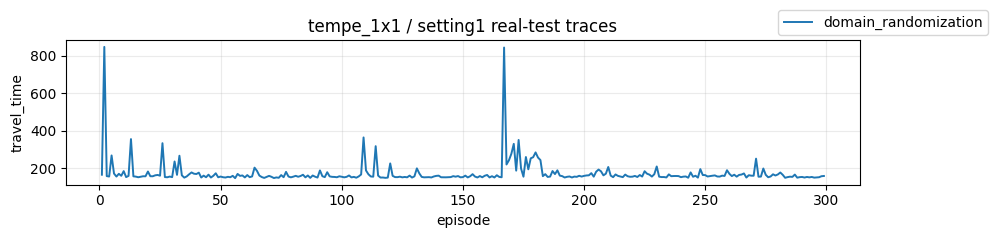

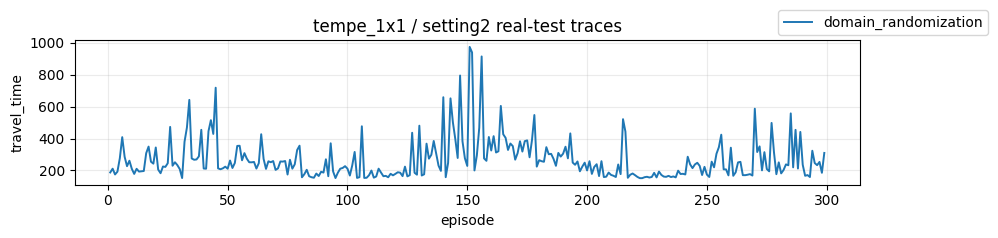

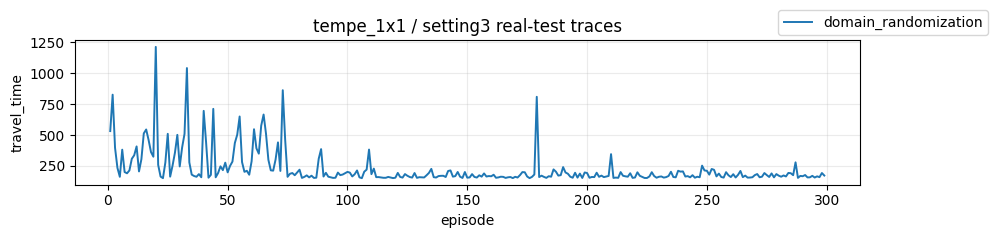

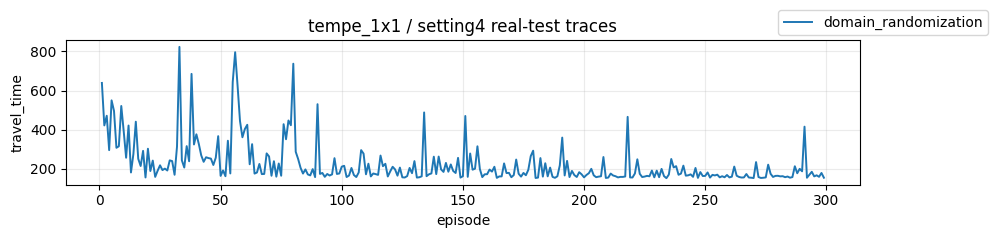

In [12]:
REAL_TRACE_NETWORKS = NETWORK_ORDER
REAL_TRACE_SETTINGS = SETTING_ORDER
REAL_TRACE_METHODS = ['domain_randomization']
REAL_TRACE_METRICS = ['travel_time']

REAL_TRACE_MODES_BY_METHOD = {
    'domain_randomization': ['TEST_REAL', 'TRAIN_REAL'],
}


def metric_trace_for_method(network: str, setting: str, method: str):
    row_df = comparison_df[
        (comparison_df['network'] == network)
        & (comparison_df['setting'] == setting)
        & (comparison_df['method'] == method)
    ]
    if row_df.empty or pd.isna(row_df.iloc[-1]['log_file']):
        return pd.DataFrame()

    log_file = row_df.iloc[-1]['log_file']
    if method == 'domain_randomization':
        candidate_dirs = [
            LOG_ROOT / network / 'domain_randomization_eval' / setting,
            LOG_ROOT / network / 'domain_randomization' / setting,
        ]
    else:
        return pd.DataFrame()

    log_path = next((candidate_dir / log_file for candidate_dir in candidate_dirs if (candidate_dir / log_file).exists()), None)
    if log_path is None:
        return pd.DataFrame()

    text = log_path.read_text().strip()
    if not text:
        return pd.DataFrame()

    trace_df = read_tabular_dtl(log_path)
    trace_df = trace_df[trace_df['mode'].isin(REAL_TRACE_MODES_BY_METHOD[method])].copy()
    if trace_df.empty:
        return trace_df

    trace_df['network'] = network
    trace_df['setting'] = setting
    trace_df['method'] = method
    trace_df['log_file'] = log_path.name
    return trace_df.sort_values('episode')


real_trace_rows = []
for network in REAL_TRACE_NETWORKS:
    for setting in REAL_TRACE_SETTINGS:
        for method in REAL_TRACE_METHODS:
            trace_df = metric_trace_for_method(network, setting, method)
            if not trace_df.empty:
                real_trace_rows.append(trace_df)

real_trace_df = (
    pd.concat(real_trace_rows, ignore_index=True)
    if real_trace_rows
    else pd.DataFrame(columns=['network', 'setting', 'method', 'episode', *METRIC_COLUMNS, 'log_file'])
)

trace_inventory_df = (
    real_trace_df.groupby(['network', 'setting', 'method', 'log_file'], dropna=False)
    .agg(episodes=('episode', 'count'), first_episode=('episode', 'min'), last_episode=('episode', 'max'))
    .reset_index()
)
display(trace_inventory_df)

for network in REAL_TRACE_NETWORKS:
    for setting in REAL_TRACE_SETTINGS:
        plot_df = real_trace_df[(real_trace_df['network'] == network) & (real_trace_df['setting'] == setting)]
        if plot_df.empty:
            continue

        metrics_to_plot = [metric for metric in REAL_TRACE_METRICS if metric in plot_df.columns and plot_df[metric].notna().any()]
        if not metrics_to_plot:
            continue

        fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 2.4 * len(metrics_to_plot)), sharex=True)
        axes = np.atleast_1d(axes)
        for ax, metric in zip(axes, metrics_to_plot):
            for method in REAL_TRACE_METHODS:
                trace_method_df = plot_df[plot_df['method'] == method]
                if trace_method_df.empty or trace_method_df[metric].isna().all():
                    continue
                ax.plot(trace_method_df['episode'], trace_method_df[metric], linewidth=1.4, label=method)
            ax.set_ylabel(metric)
            ax.grid(True, alpha=0.25)

        axes[-1].set_xlabel('episode')
        axes[0].set_title(f'{network} / {setting} real-test traces')
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0, 1.0))
        fig.tight_layout(rect=(0, 0, 0.88, 1))
        plt.show()



## Tempe 1x1 Setting Comparison

This notebook currently only has copied observation logs for `tempe_1x1`, so the tables and plots above are the main comparison view for now.
